# Load SmartSPIM Dataset with Mask at Scale 1

Configure the dataset parameters for SmartSPIM_649103_2023-07-10_19-47-40

In [1]:
from aind_octo_data_loaders.cloud_mask_dataloader import MaskedZarrDataset

# Dataset configuration
sample_id = "SmartSPIM_649103_2023-07-10_19-47-40_stitched_2023-08-23_01-29-58"
prefix = "image_tile_fusing/OMEZarr"
channels = [
    "Ex_488_Em_525.zarr",
    "Ex_561_Em_600.zarr", 
    "Ex_647_Em_690.zarr"
]

# Choose a channel to load (let's use the first one)
channel = channels[0]  # Ex_488_Em_525.zarr

# Construct the zarr file path
# Assuming S3 bucket structure: s3://bucket-name/sample_id/prefix/channel
zarr_file = f"s3://aind-open-data/{sample_id}/{prefix}/{channel}"

# Mask file path
mask_file = f"s3://aind-msma-morphology-data/test_data/SmartSPIM/smartspim_segmentation_masks/SmartSPIM_{sample_id.split('_')[1]}/segmentation_mask.zarr"

print(f"Zarr file: {zarr_file}")
print(f"Mask file: {mask_file}")

Zarr file: s3://aind-open-data/SmartSPIM_649103_2023-07-10_19-47-40_stitched_2023-08-23_01-29-58/image_tile_fusing/OMEZarr/Ex_488_Em_525.zarr
Mask file: s3://aind-msma-morphology-data/test_data/SmartSPIM/smartspim_segmentation_masks/SmartSPIM_649103/segmentation_mask.zarr


In [2]:
# Create the MaskedZarrDataset at scale 1
dataset = MaskedZarrDataset(
    sample=sample_id,
    zarr_file=zarr_file,
    mask_file=mask_file,
    scale=1,  # Scale 1 for data
    downsampled_mask_level=3, # Scale 3 for mask ROI selection
    volume_size=128,
    mask_threshold=0.5,
    do_pad_array=True,
    platform="SmartSPIM",
    block_prefilter=False,
    overlap_pct=0.0,
    force_refilter=True  # Use cached indices if available
)

print(f"\nDataset loaded successfully!")
print(f"Total volumes: {len(dataset)}")



	Using coarse prefilter from level 3 -> scale 1
	Coarse prefilter kept 6791 coarse blocks out of 18432 total.
	Expanded coarse -> full-res produced 6791 candidate blocks.

Dataset loaded successfully!
Total volumes: 6791
	Coarse prefilter kept 6791 coarse blocks out of 18432 total.
	Expanded coarse -> full-res produced 6791 candidate blocks.

Dataset loaded successfully!
Total volumes: 6791


In [3]:
# View dataset summary
dataset.summary

{'sample': 'SmartSPIM_649103_2023-07-10_19-47-40_stitched_2023-08-23_01-29-58',
 'zarr_file': 's3://aind-open-data/SmartSPIM_649103_2023-07-10_19-47-40_stitched_2023-08-23_01-29-58/image_tile_fusing/OMEZarr/Ex_488_Em_525.zarr',
 'scale': 1,
 'volume_size': 128,
 'platform': 'SmartSPIM',
 'num_volumes': 6791,
 'total_possible': 14700}

In [4]:
# Get a sample volume from the dataset
sample_data = dataset[0]

print(f"Sample data keys: {sample_data.keys()}")
print(f"Volume shape: {sample_data['volume'].shape}")
print(f"Sample: {sample_data['sample']}")
print(f"Scale: {sample_data['scale']}")
print(f"Platform: {sample_data['platform']}")
print(f"Origin (Z, Y, X): ({sample_data['Z']}, {sample_data['Y']}, {sample_data['X']})")

Sample data keys: dict_keys(['volume', 'platform', 'sample', 'scale', 'T', 'C', 'Z', 'Y', 'X'])
Volume shape: (1, 1, 128, 128, 128)
Sample: SmartSPIM_649103_2023-07-10_19-47-40_stitched_2023-08-23_01-29-58
Scale: 1
Platform: SmartSPIM
Origin (Z, Y, X): (0, 1152, 1152)


volume_data shape: (1, 1, 128, 128, 128)
slice shape: (128, 128) 3 230


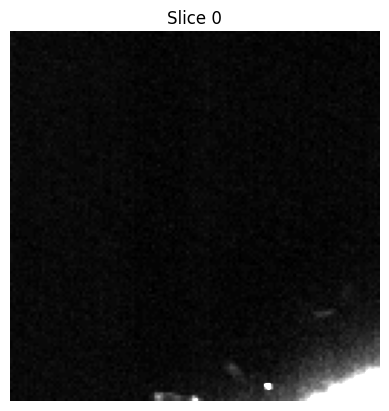

volume_data shape: (1, 1, 128, 128, 128)
slice shape: (128, 128) 3 1698


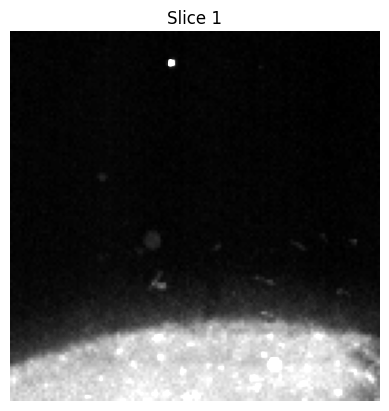

volume_data shape: (1, 1, 128, 128, 128)
slice shape: (128, 128) 2 148


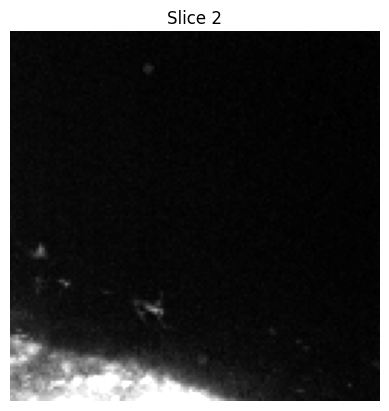

volume_data shape: (1, 1, 128, 128, 128)
slice shape: (128, 128) 2 9


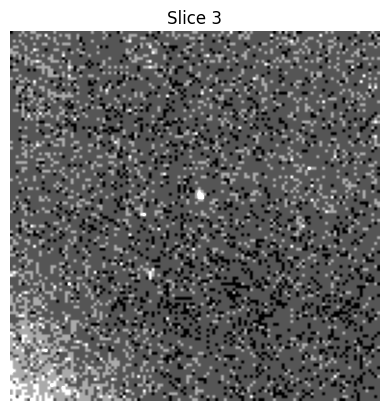

volume_data shape: (1, 1, 128, 128, 128)
slice shape: (128, 128) 3 410


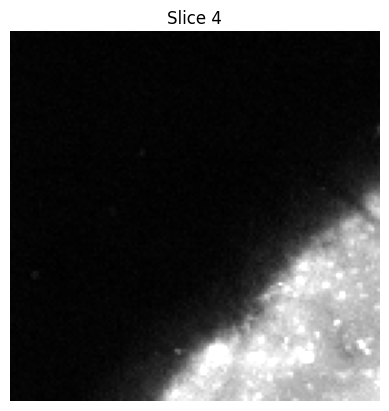

volume_data shape: (1, 1, 128, 128, 128)
slice shape: (128, 128) 4 1689


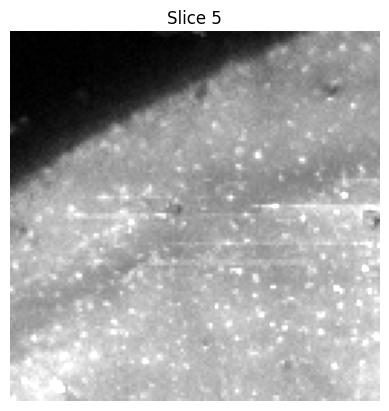

volume_data shape: (1, 1, 128, 128, 128)
slice shape: (128, 128) 45 3067


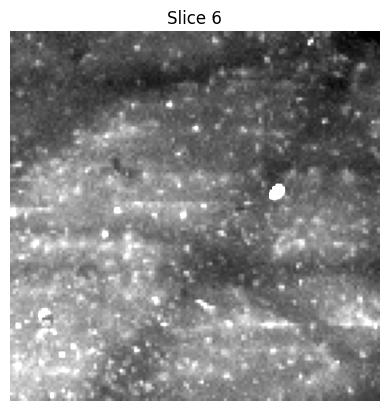

volume_data shape: (1, 1, 128, 128, 128)
slice shape: (128, 128) 3 1615


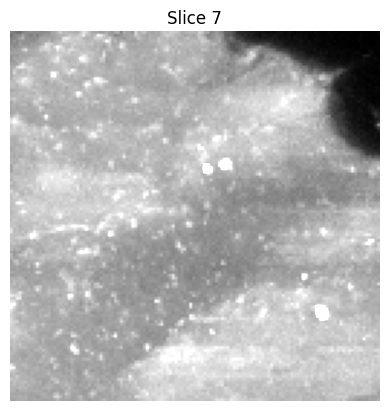

volume_data shape: (1, 1, 128, 128, 128)
slice shape: (128, 128) 2 1358


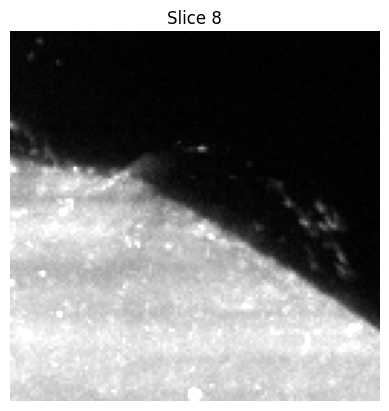

volume_data shape: (1, 1, 128, 128, 128)
slice shape: (128, 128) 2 106


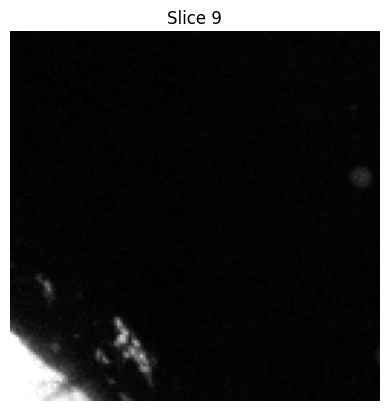

In [5]:
# plot slices of 5 blocks in the volume
import matplotlib.pyplot as plt
import numpy as np
%matplotlib inline

def plot_volume_slices(volume_data):
    print("volume_data shape:", volume_data.shape)
    # fig, axes = plt.subplots(1, 1, figsize=(15, 5))
    # for i in range(0, num_slices):
    img_slice = volume_data[0, 0]
    img_slice = np.max(img_slice, axis=0)
    print("slice shape:", img_slice.shape, img_slice.min(), img_slice.max())
    vmin, vmax = np.percentile(img_slice, (0.1, 99))
    plt.imshow(img_slice, cmap="gray", vmin=vmin, vmax=vmax)
    plt.title(f"Slice {i}")
    plt.axis("off")
    plt.show()

for i in range(0, 10):
    sample_data = dataset[i]
    plot_volume_slices(sample_data["volume"])

## Load all three channels

Load all three channels simultaneously, you can create multiple datasets or modify the loader to handle multiple channels.

In [2]:
from aind_octo_data_loaders.cloud_mask_dataloader import MaskedZarrDataset

sample_id = "SmartSPIM_649103_2023-07-10_19-47-40_stitched_2023-08-23_01-29-58"
prefix = "image_tile_fusing/OMEZarr"
channels = [
    "Ex_488_Em_525.zarr",
    "Ex_561_Em_600.zarr", 
    "Ex_647_Em_690.zarr"
]

# Choose a channel to load (let's use the first one)
channel = channels[0]  # Ex_488_Em_525.zarr

# Construct the zarr file path
# Assuming S3 bucket structure: s3://bucket-name/sample_id/prefix/channel
zarr_file = f"s3://aind-open-data/{sample_id}/{prefix}/{channel}"

# Mask file path
mask_file = f"s3://aind-msma-morphology-data/test_data/SmartSPIM/smartspim_segmentation_masks/SmartSPIM_{sample_id.split('_')[1]}/segmentation_mask.zarr"


# Example: Create datasets for all channels
datasets_by_channel = {}
for channel in channels:
    zarr_path = f"s3://aind-open-data/{sample_id}/{prefix}/{channel}"
    
    datasets_by_channel[channel] = MaskedZarrDataset(
        sample=f"{sample_id}_{channel}",
        zarr_file=zarr_path,
        mask_file=mask_file,
        scale=1,
        downsampled_mask_level=3,  # Scale 3 for mask ROI selection
        volume_size=128,
        mask_threshold=0.5,
        do_pad_array=True,
        platform="SmartSPIM",
        force_refilter=True,
        block_prefilter=False,
        overlap_pct=0.0,
    )
    
    print(f"{channel}: {len(datasets_by_channel[channel])} volumes")


	Using coarse prefilter from level 3 -> scale 1
	Coarse prefilter kept 6791 coarse blocks out of 18432 total.
	6791/14700 valid indices after masking.
Ex_488_Em_525.zarr: 6791 volumes

	Using coarse prefilter from level 3 -> scale 1
	Coarse prefilter kept 6791 coarse blocks out of 18432 total.
	6791/14700 valid indices after masking.
Ex_561_Em_600.zarr: 6791 volumes

	Using coarse prefilter from level 3 -> scale 1
	Coarse prefilter kept 6791 coarse blocks out of 18432 total.
	6791/14700 valid indices after masking.
Ex_647_Em_690.zarr: 6791 volumes


In [3]:

# Concatenate datasets into a single dataset
from torch.utils.data import ConcatDataset, DataLoader
from aind_octo_data_loaders.cloud_mask_dataloader import MaskedZarrDataset

def worker_init_fn(worker_id):
    import dask
    dask.config.set(scheduler="synchronous")  # Reinitialize safely
    # Optional: clear any global Dask client references
    from dask.distributed import default_client
    try:
        client = default_client()
        client.close()
    except Exception:
        pass

combined_dataset = ConcatDataset(list(datasets_by_channel.values()))
print(f"\nCombined dataset total volumes: {len(combined_dataset)}")

for num_workers in [0]:
    print(f"\nTesting with num_workers={num_workers}")
    train_dataloader = DataLoader(
        combined_dataset,
        batch_size=8,
        shuffle=True,
        num_workers=num_workers,
        # persistent_workers=True,
        pin_memory=True,
        # worker_init_fn=worker_init_fn,
        persistent_workers=False,
        # prefetch_factor=2,
    )
    for i, batch in enumerate(train_dataloader):
        print(f"Got batch {i}")
        if i == 2:
            break


Combined dataset total volumes: 20373

Testing with num_workers=0
Got batch 0
Got batch 1
Got batch 2


In [4]:
train_dataloader = DataLoader(
    combined_dataset,
    batch_size=8,
    shuffle=True,
    num_workers=0,
    # persistent_workers=True,
    pin_memory=True,
    # prefetch_factor=2,
)

for i, sample_data in enumerate(train_dataloader):
    # print(f"\nSample {i} data keys: {sample_data.keys()}")
    # print(f"Volume shape: {sample_data['volume'].shape}")
    # print(f"Sample: {sample_data['sample']}")
    # print(f"Scale: {sample_data['scale']}")
    # print(f"Platform: {sample_data['platform']}")
    # print(f"Origin (Z, Y, X): ({sample_data['Z']}, {sample_data['Y']}, {sample_data['X']})")
    print(sample_data.shape)
    if i >= 5:
        break

torch.Size([8, 1, 128, 128, 128])
torch.Size([8, 1, 128, 128, 128])
torch.Size([8, 1, 128, 128, 128])
torch.Size([8, 1, 128, 128, 128])
torch.Size([8, 1, 128, 128, 128])
torch.Size([8, 1, 128, 128, 128])


In [4]:
from typing import Tuple
from pathlib import Path
from typing import List
import yaml

def get_smartspim_training_data(
    bucket_name: str = "aind-open-data",
    config_filename: str = "smartspim.yaml",
):
    """Load SmartSPIM train/val S3 paths from YAML config.

    YAML expected structure (see data_configs/smartspim.yaml):
    bucket: aind-open-data
    brains: [ {id, prefix, channels: []}, ... ]
    train_split: [id, ...]
    val_split: [id, ...]

    Returns
    -------
    train_paths : List[str]
        S3 URIs for each (brain, channel) in training split.
    val_paths : List[str]
        S3 URIs for each (brain, channel) in validation split.
    """

    # Resolve config path relative to this file
    cfg_path = Path(
       "/home/camilo/refactor_lightsheet_mae/aind-lightsheet-mae/code/data_configs/smartspim.yaml"
    )
    cfg_path = cfg_path.resolve()
    if not cfg_path.is_file():
        raise FileNotFoundError(f"SmartSPIM config not found at {cfg_path}")

    try:
        with open(cfg_path, "r") as f:
            config = yaml.safe_load(f)
    except ImportError as e:
        raise ImportError(
            "PyYAML is required to load smartspim config. Install with `pip install pyyaml`."
        ) from e

    bucket = config.get("bucket", bucket_name)
    brains_cfg = config.get("brains", [])
    train_ids = set(config.get("train_split", []))
    val_ids = set(config.get("val_split", []))

    # Index brains by id for quick lookup
    brain_index = {b["id"]: b for b in brains_cfg}

    missing_train = train_ids - set(brain_index.keys())
    missing_val = val_ids - set(brain_index.keys())
    if missing_train:
        raise ValueError(
            f"Train IDs not found in brains list: {missing_train}"
        )
    if missing_val:
        raise ValueError(f"Val IDs not found in brains list: {missing_val}")

    def build_paths(id_list: set) -> List[str]:
        paths = []
        for bid in id_list:
            b = brain_index[bid]
            prefix = b.get("prefix", "")
            for ch in b.get("channels", []):
                if "488" not in ch:
                    continue

                # Construct S3 URI (assuming brain folder contains prefix then channel)
                uri = (
                    f"s3://{bucket}/{bid}/{prefix}/{ch}"
                    if prefix
                    else f"s3://{bucket}/{bid}/{ch}"
                )
                mask = b.get("mask_path", None)
                paths.append((uri, mask))
        return sorted(paths)

    train_paths = build_paths(train_ids)
    val_paths = build_paths(val_ids)

    if not len(train_paths):
        raise ValueError("No training paths generated from config.")
    if not len(val_paths):
        raise ValueError("No validation paths generated from config.")

    print(
        f"Loaded {len(train_paths)} training and {len(val_paths)} validation channel paths from {cfg_path}"
    )
    return train_paths, val_paths

def create_cloud_dataloaders(
    s3_training_paths: list,
    s3_validation_paths: list,
    img_path_size: Tuple[int, int, int],
    batch_size: int,
    num_workers: int,
    scale: int,
    transforms_train,
    transforms_test,
    train_dataloader_kwargs: dict = {},
    val_dataloader_kwargs: dict = {},
):
    """
    Create dataloaders for training and validation datasets stored in S3.
    Parameters
    ----------
    s3_training_paths : list
        List of S3 paths for training datasets.
    s3_validation_paths : list
        List of S3 paths for validation datasets.
    img_path_size : Tuple[int, int, int]
        Size of the image patches to be extracted (D, H, W).
    batch_size : int
        Batch size for the dataloaders.
    num_workers : int
        Number of workers for data loading.
    scale : int
        Scale factor for the datasets.
    train_dataloader_kwargs : dict
        Additional keyword arguments for the training dataloader.
    val_dataloader_kwargs : dict
        Additional keyword arguments for the validation dataloader.
    Returns
    -------
    train_dataloader : DataLoader
        DataLoader for the training dataset.
    val_dataloader : DataLoader
        DataLoader for the validation dataset.
    """

    # Getting pointers to s3 buckets
    # s3_training_paths = train_val_paths.get("training_paths")
    if not len(s3_training_paths):
        raise ValueError("Please, provide training paths!")
    
    # Create training dataset
    print(f"Training images from {s3_training_paths}")

    train_datasets = []
    for sample, (zarr_file, mask_file) in enumerate(s3_training_paths):
        train_datasets.append(
            MaskedZarrDataset(
                sample=sample,
                zarr_file=zarr_file,
                scale=scale,
                volume_size=img_path_size,
                do_pad_array=True,
                platform="SmartSPIM",
                overlap_pct=0.0,
                zarr_version="2.0",
                mask_file=mask_file,
                downsampled_mask_level=None,
                mask_threshold=0.5,
                force_refilter=True,
                block_prefilter=False,
                transform=transforms_train,
            )
        )

    train_datasets = ConcatDataset(train_datasets)
    print("Total training samples:", len(train_datasets))

    # Create DataLoader from the dataset
    train_dataloader = DataLoader(
        train_datasets,
        batch_size=batch_size,
        shuffle=True,
        num_workers=num_workers,
        **train_dataloader_kwargs,
    )

    if not len(s3_validation_paths):
        raise ValueError("Please, provide validation paths!")

    val_datasets = []
    for sample, (zarr_file, mask_file) in enumerate(s3_validation_paths):
        val_datasets.append(
            MaskedZarrDataset(
                sample=sample,
                zarr_file=zarr_file,
                scale=scale,
                volume_size=img_path_size,
                do_pad_array=True,
                platform="SmartSPIM",
                overlap_pct=0.0,
                zarr_version="2.0",
                mask_file=mask_file,
                downsampled_mask_level=None,
                mask_threshold=0.5,
                force_refilter=True,
                block_prefilter=False,
                transform=transforms_test,
            )
        )

    val_datasets = ConcatDataset(val_datasets)
    print("Total validation samples:", len(val_datasets))

    # Create DataLoader from the dataset
    val_dataloader = DataLoader(
        val_datasets,
        batch_size=batch_size,
        shuffle=True,
        num_workers=num_workers,
        **val_dataloader_kwargs,
    )

    print(f"Validation images from {s3_validation_paths}")
    return train_dataloader, val_dataloader

In [5]:
train_path, validation_path = get_smartspim_training_data(
    bucket_name="aind-open-data",
)

Loaded 4 training and 1 validation channel paths from /home/camilo/refactor_lightsheet_mae/aind-lightsheet-mae/code/data_configs/smartspim.yaml


In [6]:
"""
Augmentations for training 3D MAE models using MONAI.
Ensures outputs are torch.float32 tensors.
"""

import torch
from monai.transforms import (Compose, EnsureChannelFirstd, EnsureTyped,
                              NormalizeIntensityd, RandAdjustContrastd,
                              RandAffined, RandFlipd, RandGaussianNoised,
                              RandRotated, RandSpatialCropd, ToTensord)


def train_augmentations():
    """Version using MONAI's built-in normalization instead of custom"""
    return Compose(
        [
            # Geometric transformations (same as above)
            RandFlipd(keys=["image"], prob=0.5, spatial_axis=0),
            RandFlipd(keys=["image"], prob=0.5, spatial_axis=1),
            RandFlipd(keys=["image"], prob=0.5, spatial_axis=2),
            # RandRotated(
            #     keys=["image"],
            #     range_x=0.174, range_y=0.174, range_z=0.174,
            #     prob=0.5,
            #     mode=["bilinear"],
            #     padding_mode="zeros",
            # ),
            # RandAffined(
            #     keys=["image"],
            #     rotate_range=[0.087, 0.087, 0.087],
            #     translate_range=[6, 6, 6],
            #     scale_range=[0.05, 0.05, 0.05],
            #     prob=0.4,
            #     mode=["bilinear"],
            #     padding_mode="zeros",
            # ),
            # RandSpatialCropd(
            #     keys=["image"],
            #     roi_size=(128, 128, 128),
            #     random_center=True,
            #     # prob=0.5,
            # ),
            # Intensity
            # RandGaussianNoised(keys=["image"], prob=0.3, std=0.1),
            # RandAdjustContrastd(keys=["image"], prob=0.3, gamma=(0.8, 1.2)),
            # Built-in normalization (scales to [0,1] then z-score)
            NormalizeIntensityd(keys=["image"]),  # Z-score normalization
            ToTensord(keys=["image"], dtype=torch.float32),  # enforce float32
            # EnsureTyped(keys=["image"], data_type="tensor"),
        ]
    )


def val_augmentations():
    """Version using MONAI's built-in normalization instead of custom"""
    return Compose(
        [
            NormalizeIntensityd(keys=["image"]),  # Z-score normalization
            ToTensord(keys=["image"], dtype=torch.float32),  # enforce float32
            # EnsureTyped(keys=["image"], data_type="tensor"),
        ]
    )


/home/camilo/.conda/envs/new_mae_310/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [7]:
transforms_train = train_augmentations()
transforms_test = val_augmentations()
dataloader_config = {
    # "prefetch_factor": 2,
    "pin_memory": True,
    # "persistent_workers": True,
}

train_dataloader, val_dataloader = create_cloud_dataloaders(
    s3_training_paths=train_path,
    s3_validation_paths=validation_path,
    img_path_size=128,
    batch_size=4,
    num_workers=0,
    scale=1,
    train_dataloader_kwargs=dataloader_config,
    val_dataloader_kwargs=dataloader_config,
    transforms_train=transforms_train,
    transforms_test=transforms_test,
)

Training images from [('s3://aind-open-data/SmartSPIM_649103_2023-07-10_19-47-40_stitched_2023-08-23_01-29-58/image_tile_fusing/OMEZarr/Ex_488_Em_525.zarr', 's3://aind-msma-morphology-data/test_data/SmartSPIM/smartspim_segmentation_masks/SmartSPIM_649103/segmentation_mask.zarr'), ('s3://aind-open-data/SmartSPIM_657882_2023-06-29_16-17-26_stitched_2023-07-20_19-38-09/image_tile_fusing/OMEZarr/Ex_488_Em_525.zarr', 's3://aind-msma-morphology-data/test_data/SmartSPIM/smartspim_segmentation_masks/SmartSPIM_657882/segmentation_mask.zarr'), ('s3://aind-open-data/SmartSPIM_659012_2023-06-30_15-58-42_stitched_2023-07-19_01-51-58/image_tile_fusing/OMEZarr/Ex_488_Em_525.zarr', 's3://aind-msma-morphology-data/test_data/SmartSPIM/smartspim_segmentation_masks/SmartSPIM_659012/segmentation_mask.zarr'), ('s3://aind-open-data/SmartSPIM_685111_2023-09-28_18-19-10_stitched_2024-01-11_10-16-44/image_tile_fusing/OMEZarr/Ex_488_Em_525.zarr', 's3://aind-msma-morphology-data/test_data/SmartSPIM/smartspim_segm

In [8]:
limit = 20
for i, sample_data in enumerate(train_dataloader):
    print("Train dataloader: ", sample_data.shape)
    if i >= limit:
        break

for i, sample_data in enumerate(val_dataloader):
    print("Val dataloader: ", sample_data.shape)
    if i >= limit:
        break

Train dataloader:  torch.Size([4, 1, 128, 128, 128])
Train dataloader:  torch.Size([4, 1, 128, 128, 128])
Train dataloader:  torch.Size([4, 1, 128, 128, 128])
Train dataloader:  torch.Size([4, 1, 128, 128, 128])
Train dataloader:  torch.Size([4, 1, 128, 128, 128])
Train dataloader:  torch.Size([4, 1, 128, 128, 128])
Train dataloader:  torch.Size([4, 1, 128, 128, 128])
Train dataloader:  torch.Size([4, 1, 128, 128, 128])
Train dataloader:  torch.Size([4, 1, 128, 128, 128])
Train dataloader:  torch.Size([4, 1, 128, 128, 128])
Train dataloader:  torch.Size([4, 1, 128, 128, 128])
Train dataloader:  torch.Size([4, 1, 128, 128, 128])
Train dataloader:  torch.Size([4, 1, 128, 128, 128])
Train dataloader:  torch.Size([4, 1, 128, 128, 128])
Train dataloader:  torch.Size([4, 1, 128, 128, 128])
Train dataloader:  torch.Size([4, 1, 128, 128, 128])
Train dataloader:  torch.Size([4, 1, 128, 128, 128])
Train dataloader:  torch.Size([4, 1, 128, 128, 128])
Train dataloader:  torch.Size([4, 1, 128, 128,